## Issue Alignment
To what extent do our 20 issues collapse onto a single LR axis?

In [7]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
pub_folder = "../survey_data"

# Load likert responses and stance dictionary
likert = pd.read_csv(f"{pub_folder}/likert-responses.csv")
stance_dict = pd.read_csv("stance_dict.csv")

# Build response -> numeric score lookup
score_lookup = dict(
    zip(
        stance_dict["response"],
        stance_dict["polarity"].map({"conservative": 1, "liberal": -1}),
    )
)

# Each (respondent, issue) has multiple rows (one per question/model), but user_stance
# should be identical across all of them
stance_rows = likert[["respondent_id", "issue", "user_stance"]]
stance_rows = stance_rows.drop_duplicates(subset=["respondent_id", "issue"])

# Pivot to wide format: rows = respondents, columns = issues
df_wide = stance_rows.pivot(index="respondent_id", columns="issue", values="user_stance")
df_wide.columns.name = None

# Save respondent ID column aligned with df_wide
prolific_id_col = pd.Series(df_wide.index, name="respondent_id").reset_index(drop=True)

# Error check: count non-empty cells that don't match any known response
unmatched = 0
for col in df_wide.columns:
    series = df_wide[col]
    non_empty = series.notna() & (series != "")
    no_match = ~series.isin(score_lookup.keys())
    unmatched += (non_empty & no_match).sum()
print(f"Unmatched (non-empty, unrecognized) cells: {unmatched}")

# Recode stances to -1 / +1 / NaN
df_stance = df_wide.apply(lambda col: col.map(score_lookup)).reset_index(drop=True)

print(df_stance.head())

Unmatched (non-empty, unrecognized) cells: 0
   abortion  affirmative_action  birthright_citizenship  carbon_tax  \
0       NaN                 NaN                     NaN         NaN   
1       NaN                 NaN                     NaN        -1.0   
2       NaN                 NaN                     NaN         NaN   
3       NaN                 1.0                     NaN         1.0   
4       NaN                 1.0                     NaN         NaN   

   child_labor  death_penalty  dei  deportation  electoral_college  \
0          NaN            NaN  NaN         -1.0                NaN   
1          NaN            NaN -1.0          NaN                NaN   
2          NaN            NaN  NaN          NaN                NaN   
3          NaN           -1.0  NaN          NaN                1.0   
4          NaN            NaN  NaN          NaN                NaN   

   gun_control  hate_speech  healthcare  labor_unions  min_wage  \
0          NaN          NaN         1.0 

In [9]:
# Load demographics from public dataset
prolific = pd.read_csv(f"{pub_folder}/participant_demographics.csv")
print(f"Loaded {len(prolific)} participants")

# Build respondent_id -> political spectrum lookup
pid_to_polspec = prolific.set_index("respondent_id")["Political spectrum (us)"].to_dict()

# Map each respondent row to their political spectrum label, then to a numeric score
# Liberal = -1, Moderate = 0, Conservative = 1  (NaN for missing)
polspec_series = prolific_id_col.map(pid_to_polspec)
polspec_numeric = polspec_series.map({"Liberal": -1, "Moderate": 0, "Conservative": 1})
print(polspec_series.value_counts(dropna=False))

# Drop rows with no matched political spectrum
valid = polspec_numeric.notna()
df_stance = df_stance[valid].reset_index(drop=True)
prolific_id_col = prolific_id_col[valid].reset_index(drop=True)
polspec_series = polspec_series[valid].reset_index(drop=True)
polspec_numeric = polspec_numeric[valid].reset_index(drop=True)
print(f"After dropping unmatched rows: {len(df_stance)} respondents remain")

Loaded 7434 participants
respondent_id
Liberal         3184
Conservative    3061
Moderate        1189
Name: count, dtype: int64
After dropping unmatched rows: 7434 respondents remain


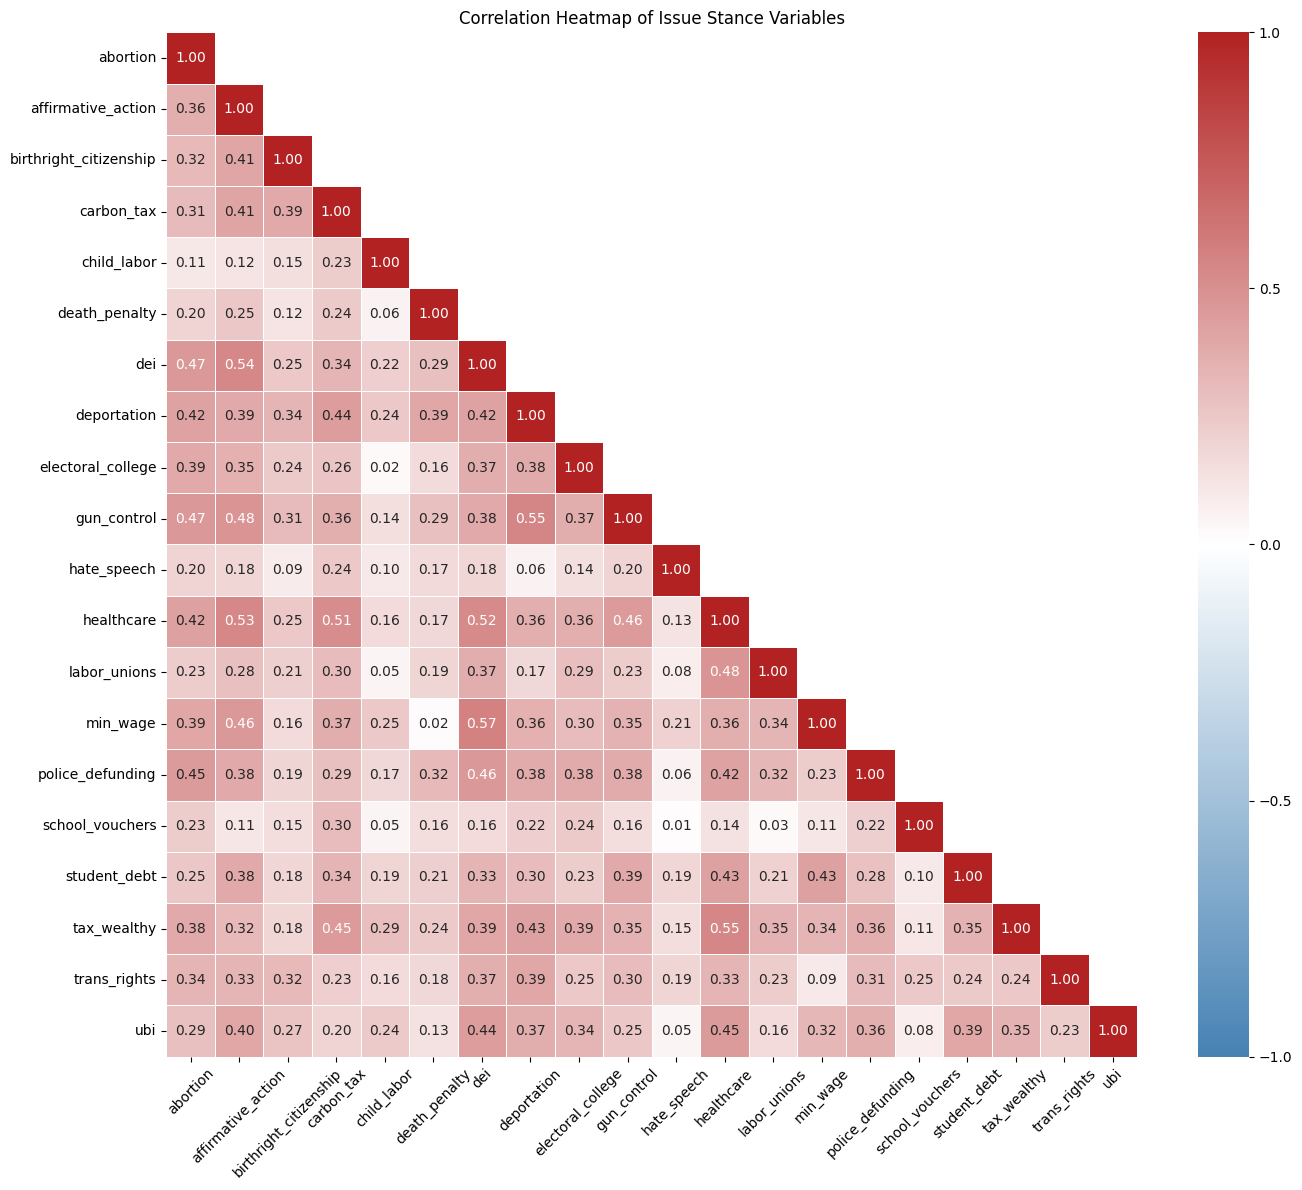

In [10]:
# Compute pairwise correlation matrix
cor_mat = df_stance.corr(method="pearson", min_periods=1)

cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    "steelblue_firebrick", ["steelblue", "white", "firebrick"]
)

mask = np.triu(np.ones_like(cor_mat, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cor_mat,
    mask=mask,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    ax=ax,
    cbar_kws={"ticks": [-1, -0.5, 0, 0.5, 1]},
    linewidths=0.5,
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=45)
ax.set_title("Correlation Heatmap of Issue Stance Variables")
plt.tight_layout()
plt.savefig("../figures/issue-stance-correlation.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

7434 rows, 20 columns before imputation
DEI x1 = -1.968
Flipped PC1 sign so conservative is on the right


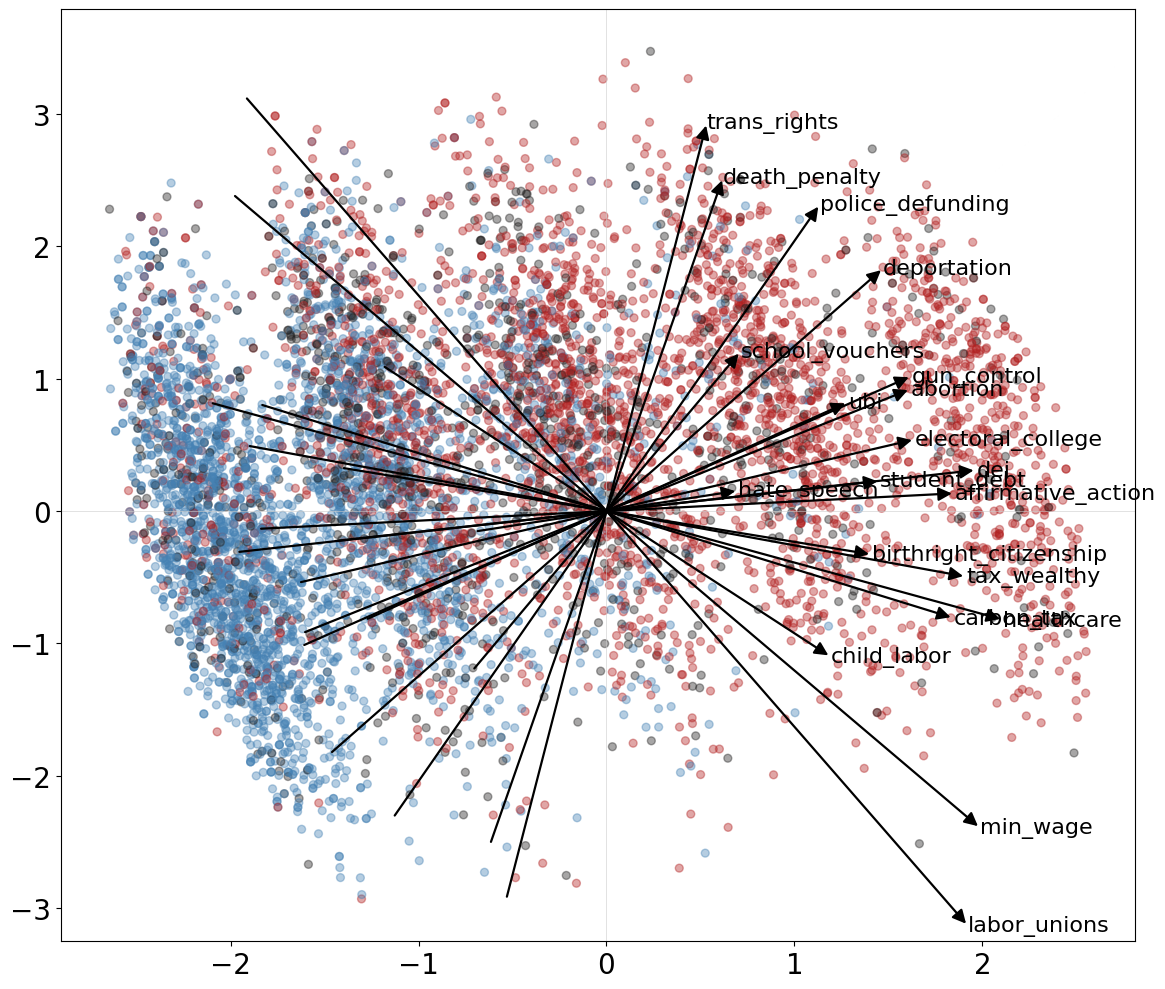

In [11]:
# Drop all-NA columns
all_na_cols = df_stance.isna().all()
if all_na_cols.any():
    print(f"Dropping all-NA columns: {list(df_stance.columns[all_na_cols])}")
df_pca = df_stance.loc[:, ~all_na_cols].copy()

# Drop zero-variance columns
nonzero_var = df_pca.var() > 0
if (~nonzero_var).any():
    print(f"Dropping zero-variance columns: {list(df_pca.columns[~nonzero_var])}")
df_pca = df_pca.loc[:, nonzero_var]

print(f"{df_pca.shape[0]} rows, {df_pca.shape[1]} columns before imputation")

# Impute NAs with 0 (treat missing answers as neutral)
df_imputed = df_pca.fillna(0.0)

# Scale by std but do NOT subtract the mean (center at the neutral point 0, not the sample mean)
col_sds = df_imputed.std()
df_scaled_zero = df_imputed / col_sds

# Uncentered PCA via SVD
U, S, Vt = np.linalg.svd(df_scaled_zero.values, full_matrices=False)

# Respondent scores on PC1 and PC2
pca_scores = pd.DataFrame(
    {
        "PC1": U[:, 0] * S[0],
        "PC2": U[:, 1] * S[1],
        "polspec": polspec_numeric.values,
    }
)

# Issue vectors: project ±3 unit change in each issue through the rotation matrix
rotation = Vt.T  # shape: (n_features, n_components)
n_issues = df_imputed.shape[1]
issue_vectors = []
for i, issue_name in enumerate(df_imputed.columns):
    v_neg = np.zeros(n_issues)
    v_pos = np.zeros(n_issues)
    v_neg[i] = -3
    v_pos[i] = 3
    p_neg = (v_neg / col_sds.values) @ rotation[:, :2]
    p_pos = (v_pos / col_sds.values) @ rotation[:, :2]
    issue_vectors.append(
        {"issue": issue_name, "x0": p_neg[0], "y0": p_neg[1], "x1": p_pos[0], "y1": p_pos[1]}
    )
issue_df = pd.DataFrame(issue_vectors)

# Flip PC1 if needed so conservative stance (DEI positive end) is on the right
dei_x1 = issue_df.loc[issue_df["issue"] == "dei", "x1"].values[0]
print(f"DEI x1 = {dei_x1:.3f}")
if dei_x1 < 0:
    pca_scores["PC1"] *= -1
    issue_df["x0"] *= -1
    issue_df["x1"] *= -1
    print("Flipped PC1 sign so conservative is on the right")

# Plot
partisan_cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    "sb_grey_fr", ["steelblue", "#222222", "firebrick"]
)

fig, ax = plt.subplots(figsize=(12, 10))
ax.axhline(0, color="#cccccc", linewidth=0.4)
ax.axvline(0, color="#cccccc", linewidth=0.4)

ax.scatter(
    pca_scores["PC1"],
    pca_scores["PC2"],
    c=pca_scores["polspec"],
    cmap=partisan_cmap,
    vmin=-1,
    vmax=1,
    alpha=0.4,
    s=32,
)

for _, row in issue_df.iterrows():
    ax.annotate(
        "",
        xy=(row.x1, row.y1),
        xytext=(row.x0, row.y0),
        arrowprops=dict(arrowstyle="-|>", color="black", lw=1.6, mutation_scale=20),
    )
    ax.text(row.x1, row.y1, row.issue, fontsize=16, ha="left", va="center")

ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(labelsize=20)
plt.tight_layout()
plt.savefig("../figures/issue-stance-pca.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

In [12]:
# Mean stance vector across all respondents for each issue
sample_mean_vector = df_pca.mean()
print(sample_mean_vector)

abortion                 -0.294667
affirmative_action       -0.376694
birthright_citizenship   -0.380054
carbon_tax               -0.469717
child_labor              -0.433834
death_penalty             0.074866
dei                      -0.441176
deportation              -0.121457
electoral_college        -0.380376
gun_control              -0.237710
hate_speech              -0.105263
healthcare               -0.507422
labor_unions             -0.695506
min_wage                 -0.593854
police_defunding          0.030790
school_vouchers          -0.134328
student_debt             -0.274549
tax_wealthy              -0.478203
trans_rights              0.287169
ubi                      -0.137701
dtype: float64
